# Sound Synthesis
Generates Rocky-like audio from sine wave math. See `docs/synthesize_data.md` for theory.

In [2]:
import numpy as np
import scipy.io.wavfile as wav
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import spectrogram as scipy_spectrogram
from IPython.display import Audio, display
import json, os

os.makedirs('../audio', exist_ok=True)
os.makedirs('../data', exist_ok=True)
print('ready')

ready


## Constants

In [3]:
SAMPLE_RATE = 44100   # samples per second (CD quality)
GAP = 0.08            # silence between sound units in seconds

## Sound primitives
Four building blocks: `click` `hum` `chirp` `chord`

In [4]:
def silence(dur=GAP):
    return np.zeros(int(SAMPLE_RATE * dur))

def click(duration=0.04, frequency=1200, decay=30):
    # sine wave * exponential decay envelope
    t = np.linspace(0, duration, int(SAMPLE_RATE * duration))
    return (np.sin(2 * np.pi * frequency * t) * np.exp(-decay * t)).astype(np.float64)

def hum(duration=0.3, frequency=400, vibrato_rate=5, vibrato_depth=10):
    # sustained tone with pitch wobble + smooth fade in/out
    t = np.linspace(0, duration, int(SAMPLE_RATE * duration))
    wave = np.sin(2 * np.pi * (frequency + vibrato_depth * np.sin(2 * np.pi * vibrato_rate * t)) * t)
    fade = np.ones_like(t)
    n = int(0.02 * SAMPLE_RATE)
    fade[:n] = np.linspace(0, 1, n)
    fade[-n:] = np.linspace(1, 0, n)
    return (wave * fade * 0.7).astype(np.float64)

def chirp(duration=0.15, freq_start=300, freq_end=2000):
    # integrate changing frequency to get correct continuous phase
    t = np.linspace(0, duration, int(SAMPLE_RATE * duration))
    phase = 2 * np.pi * np.cumsum(np.linspace(freq_start, freq_end, len(t))) / SAMPLE_RATE
    env = np.linspace(0, 1, len(t)) * np.exp(-3 * t / duration)
    return (np.sin(phase) * env / (env.max() + 1e-9) * 0.8).astype(np.float64)

def chord(duration=0.25, frequencies=[400, 600, 900]):
    # superposition of sine waves, normalized by count
    t = np.linspace(0, duration, int(SAMPLE_RATE * duration))
    wave = sum(np.sin(2 * np.pi * f * t) for f in frequencies) / len(frequencies)
    fade = np.ones_like(t)
    n = int(0.02 * SAMPLE_RATE)
    fade[:n] = np.linspace(0, 1, n)
    fade[-n:] = np.linspace(1, 0, n)
    return (wave * fade * 0.7).astype(np.float64)

def normalize(audio):
    peak = np.max(np.abs(audio))
    return audio / peak if peak > 0 else audio

print('primitives ready')

primitives ready


## Preview each primitive

In [5]:
for name, audio in [
    ('click  1200 Hz', click(frequency=1200)),
    ('hum    400 Hz',  hum(frequency=400)),
    ('chirp  up',      chirp(freq_start=200, freq_end=2000)),
    ('chord  3 tones', chord(frequencies=[300, 450, 600])),
]:
    print(name)
    display(Audio(normalize(audio), rate=SAMPLE_RATE))

click  1200 Hz


hum    400 Hz


chirp  up


chord  3 tones


## Vocabulary — named sound units

In [6]:
SOUNDS = {
    'click_low'    : lambda: click(frequency=600,  duration=0.035),
    'click_mid'    : lambda: click(frequency=1200, duration=0.040),
    'click_high'   : lambda: click(frequency=2400, duration=0.030),
    'hum_low'      : lambda: hum(frequency=200, duration=0.30),
    'hum_mid'      : lambda: hum(frequency=450, duration=0.25),
    'hum_high'     : lambda: hum(frequency=800, duration=0.20),
    'chirp_up'     : lambda: chirp(freq_start=200,  freq_end=1800, duration=0.15),
    'chirp_down'   : lambda: chirp(freq_start=1800, freq_end=200,  duration=0.15),
    'chord_simple' : lambda: chord(frequencies=[300, 450],           duration=0.20),
    'chord_rich'   : lambda: chord(frequencies=[200, 400, 600],      duration=0.30),
    'chord_alien'  : lambda: chord(frequencies=[333, 555, 777, 999], duration=0.25),
}
print(f'{len(SOUNDS)} sound units')

11 sound units


## Sentences — sequences of sound units with known meanings

In [7]:
SENTENCES = {
    'greeting'     : ['click_high', 'click_high', 'hum_mid', 'chirp_up', 'click_mid'],
    'question'     : ['hum_low', 'click_mid', 'click_low', 'chirp_up', 'chirp_up'],
    'danger'       : ['chirp_down', 'chirp_down', 'chord_alien', 'click_high', 'click_high', 'click_high'],
    'i_understand' : ['chord_simple', 'hum_mid', 'click_low', 'hum_high', 'chord_rich'],
    'help_needed'  : ['chirp_up', 'chord_alien', 'hum_low', 'chirp_down', 'click_high', 'chord_rich'],
}
for name, sounds in SENTENCES.items():
    print(f'{name:15} {" → ".join(sounds)}')

greeting        click_high → click_high → hum_mid → chirp_up → click_mid
question        hum_low → click_mid → click_low → chirp_up → chirp_up
danger          chirp_down → chirp_down → chord_alien → click_high → click_high → click_high
i_understand    chord_simple → hum_mid → click_low → hum_high → chord_rich
help_needed     chirp_up → chord_alien → hum_low → chirp_down → click_high → chord_rich


## Synthesize and listen to each sentence

In [8]:
def make_sentence(sound_names):
    parts = []
    for name in sound_names:
        parts.append(SOUNDS[name]())
        parts.append(silence())
    return np.concatenate(parts)

sentence_audio = {}
for name, sounds in SENTENCES.items():
    audio = normalize(make_sentence(sounds))
    sentence_audio[name] = audio
    print(f'--- {name} ---')
    display(Audio(audio, rate=SAMPLE_RATE))

--- greeting ---


--- question ---


--- danger ---


--- i_understand ---


--- help_needed ---


## Save full conversation as WAV

In [9]:
pause = np.zeros(int(SAMPLE_RATE * 0.4))
full_audio = normalize(np.concatenate(
    [part for audio in sentence_audio.values() for part in [audio, pause]]
))
wav.write('../audio/rocky_voice.wav', SAMPLE_RATE, (full_audio * 32767).astype(np.int16))
print(f'saved  audio/rocky_voice.wav  ({len(full_audio)/SAMPLE_RATE:.2f}s)')
display(Audio(full_audio, rate=SAMPLE_RATE))

saved  audio/rocky_voice.wav  (8.14s)


## Visualize — waveform, spectrogram, FFT spectrum

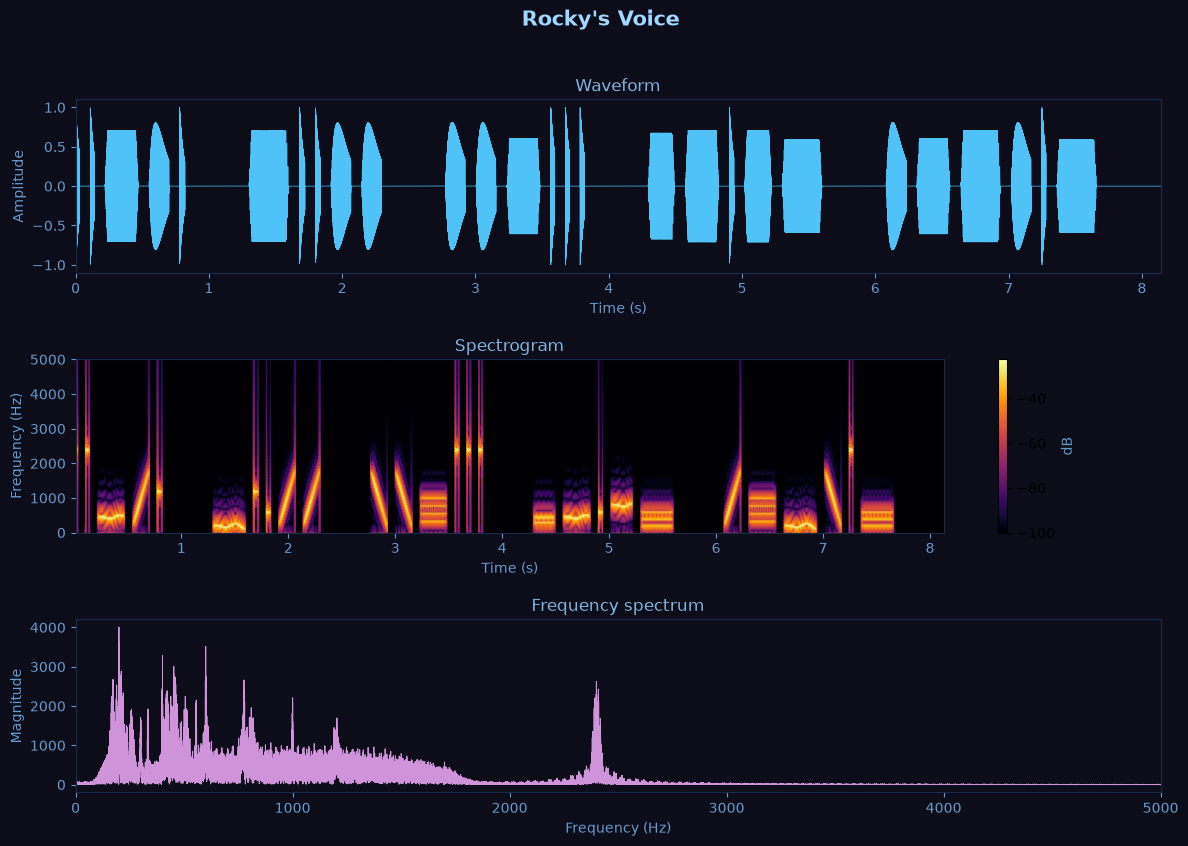

In [10]:
fig = plt.figure(figsize=(14, 9), facecolor='#0d0d1a')
fig.suptitle("Rocky's Voice", color='#a0d8ff', fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(3, 1, hspace=0.5)
ax1, ax2, ax3 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])

for ax in [ax1, ax2, ax3]:
    ax.set_facecolor('#0d0d1a')
    ax.tick_params(colors='#6699cc')
    ax.xaxis.label.set_color('#6699cc')
    ax.yaxis.label.set_color('#6699cc')
    for s in ax.spines.values(): s.set_edgecolor('#1a2a4a')

t_axis = np.linspace(0, len(full_audio) / SAMPLE_RATE, len(full_audio))

ax1.plot(t_axis, full_audio, color='#4fc3f7', linewidth=0.5)
ax1.set(title='Waveform', xlabel='Time (s)', ylabel='Amplitude', xlim=(0, t_axis[-1]))
ax1.title.set_color('#80b4e0')

f, t_s, Sxx = scipy_spectrogram(full_audio, fs=SAMPLE_RATE, nperseg=1024, noverlap=768)
im = ax2.pcolormesh(t_s, f, 10 * np.log10(Sxx + 1e-10), shading='gouraud', cmap='inferno')
ax2.set_ylim(0, 5000)
ax2.set(title='Spectrogram', xlabel='Time (s)', ylabel='Frequency (Hz)')
ax2.title.set_color('#80b4e0')
plt.colorbar(im, ax=ax2).set_label('dB', color='#6699cc')

ax3.plot(np.fft.rfftfreq(len(full_audio), 1/SAMPLE_RATE),
         np.abs(np.fft.rfft(full_audio)), color='#ce93d8', linewidth=0.7)
ax3.set_xlim(0, 5000)
ax3.set(title='Frequency spectrum', xlabel='Frequency (Hz)', ylabel='Magnitude')
ax3.title.set_color('#80b4e0')

plt.savefig('../audio/rocky_visualization.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

## Save dictionary

In [11]:
dictionary = {
    'vocabulary'     : list(SOUNDS.keys()),
    'sentences'      : SENTENCES,
    'english_meaning': {
        'greeting'     : 'Hello / I am here',
        'question'     : 'What is this?',
        'danger'       : 'Warning! Danger!',
        'i_understand' : 'I understand',
        'help_needed'  : 'I need help',
    },
    'cluster_map': {}
}
with open('../data/dictionary.json', 'w') as f:
    json.dump(dictionary, f, indent=2)
print('saved  data/dictionary.json')

saved  data/dictionary.json
